# DAY 8 - EDA: Exploratory Data Analysis

## What is EDA?

**EDA (Exploratory Data Analysis)** is the process of examining and understanding a dataset before performing advanced analysis or building machine learning models.

It is the **first step in every data analysis project** because it helps us understand the structure, quality, and patterns present in the data.

### Goal of EDA

The main goal of EDA is to understand the data before making any business decisions or creating predictive models.

EDA helps answer questions such as:

- What columns are available in the dataset?
- What data type does each column contain?
- How are values distributed?
- Are there any missing values?
- Are there any unusual values (outliers)?
- Are variables related to each other?
- What business insights can be extracted?

### Why EDA is Important?

Without EDA, analysts may work with incorrect assumptions and produce misleading results.

EDA helps us:

- Understand the dataset structure
- Detect data quality issues
- Discover patterns and trends
- Identify relationships between variables
- Generate valuable business insights

---

## EDA Framework

A typical EDA process follows these steps:

```text
1. Data Overview (shape, types, sample)
2. Missing Value Analysis
3. Univariate Analysis (one column at a time)
4. Bivariate Analysis (two columns together)
5. Multivariate Analysis (multiple columns)
6. Correlation Analysis
7. Business Insights & Summary

## Importing Required Libraries

Before starting EDA, we need to import the libraries required for data manipulation, visualization, and statistical analysis.

### Libraries Used

- **Pandas**: Used for loading, cleaning, and analyzing datasets.
- **NumPy**: Provides numerical operations and array-based computations.
- **Matplotlib**: Used for creating basic charts and visualizations.
- **Seaborn**: Built on Matplotlib and provides attractive statistical visualizations.
- **SciPy Stats**: Used for statistical calculations and analysis.

### Additional Settings

We also configure some display and visualization settings:

- Set a default figure size for plots.
- Apply a clean Seaborn theme for better-looking charts.
- Display up to 20 columns when viewing DataFrames.
- Print a confirmation message after all libraries are loaded.

These libraries form the foundation of most Data Analysis and EDA projects in Python.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
print('Libraries loaded!')

Libraries loaded!


## Creating the E-Commerce Sales Dataset

For this EDA project, we create a realistic e-commerce sales dataset containing **1,000 customer orders**.

The dataset includes information related to:

- Customer demographics
- Product categories
- Product pricing
- Discounts
- Regions
- Shipping methods
- Customer ratings
- Product returns
- Sales performance

### Features Included

Some important columns in the dataset are:

- **order_id** – Unique identifier for each order
- **order_date** – Date when the order was placed
- **customer_age** – Age of the customer
- **customer_gender** – Gender of the customer
- **category** – Product category
- **product_price** – Price of the product
- **quantity** – Number of items purchased
- **discount_pct** – Discount applied on the order
- **region** – Customer region
- **shipping_mode** – Delivery method used
- **rating** – Customer satisfaction rating
- **returned** – Indicates whether the product was returned

### Feature Engineering

Additional columns are created to make analysis easier:

- **sales_amount** – Final sales value after applying discounts
- **month** – Month name extracted from order date
- **month_num** – Month number for sorting and analysis
- **day_of_week** – Day on which the order was placed

### Introducing Missing Values

To simulate real-world data quality issues, some missing values are intentionally added to:

- **customer_age**
- **rating**

This allows us to practice missing value analysis during EDA.

Finally, we verify that the dataset has been created successfully by checking its shape (rows and columns).

In [4]:
# Generate realistic e-commerce dataset
np.random.seed(42)
n = 1000

categories = ['Electronics', 'Clothing', 'Books', 'Home & Garden', 'Sports', 'Beauty']
regions = ['North', 'South', 'East', 'West']
ship_modes = ['Standard', 'Express', 'Overnight']
months = pd.date_range('2023-01-01', periods=12, freq='MS')

df = pd.DataFrame({
    'order_id': range(1001, 1001 + n),
    'order_date': np.random.choice(pd.date_range('2023-01-01', '2023-12-31'), n),
    'customer_age': np.random.randint(18, 65, n),
    'customer_gender': np.random.choice(['Male', 'Female', 'Other'], n, p=[0.5, 0.45, 0.05]),
    'category': np.random.choice(categories, n, p=[0.25, 0.20, 0.15, 0.15, 0.15, 0.10]),
    'product_price': np.random.exponential(3000, n).astype(int) + 500,
    'quantity': np.random.randint(1, 6, n),
    'discount_pct': np.random.choice([0, 5, 10, 15, 20, 25], n, p=[0.3, 0.15, 0.25, 0.15, 0.10, 0.05]),
    'region': np.random.choice(regions, n, p=[0.3, 0.25, 0.25, 0.20]),
    'shipping_mode': np.random.choice(ship_modes, n, p=[0.5, 0.35, 0.15]),
    'rating': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.20, 0.40, 0.25]),
    'returned': np.random.choice([True, False], n, p=[0.08, 0.92])
})

# Calculated columns
df['sales_amount'] = (df['product_price'] * df['quantity'] * (1 - df['discount_pct']/100)).astype(int)
df['month'] = df['order_date'].dt.month_name()
df['month_num'] = df['order_date'].dt.month
df['day_of_week'] = df['order_date'].dt.day_name()

# Add some missing values
df.loc[np.random.choice(df.index, 30), 'customer_age'] = np.nan
df.loc[np.random.choice(df.index, 20), 'rating'] = np.nan

print('Dataset Created!')
print(f'Shape: {df.shape}')

Dataset Created!
Shape: (1000, 16)


## STEP 1: Data Overview

The first step in EDA is to get a quick understanding of the dataset structure.

### Why Perform Data Overview?

Before analyzing data, we need to know:

- How many records are available
- How many features (columns) exist
- What the dataset looks like
- Whether the data has been loaded correctly

### Dataset Shape

The `shape` attribute provides:

- Number of rows (observations)
- Number of columns (features)

This helps us understand the size of the dataset.

### Viewing Sample Data

#### `df.head()`

Displays the first 5 rows of the dataset.

This helps us:

- Verify the dataset loaded correctly
- Understand column values
- Identify possible data quality issues

#### `df.tail(3)`

Displays the last 3 rows of the dataset.

This is useful for:

- Inspecting records at the end of the dataset
- Ensuring data is complete
- Spotting any unusual values

### Summary

Data Overview provides a quick snapshot of the dataset and helps us become familiar with its structure before performing deeper analysis.

In [5]:
print('='*60)
print('STEP 1: DATA OVERVIEW')
print('='*60)

print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
print('\nFirst 5 rows:')
print(df.head())
print('\nLast 3 rows:')
print(df.tail(3))

STEP 1: DATA OVERVIEW
Dataset Shape: 1000 rows, 16 columns

First 5 rows:
   order_id order_date  customer_age customer_gender       category  \
0      1001 2023-04-13          60.0            Male       Clothing   
1      1002 2023-12-15          20.0            Male  Home & Garden   
2      1003 2023-09-28          50.0          Female       Clothing   
3      1004 2023-04-17          23.0            Male       Clothing   
4      1005 2023-03-13          27.0          Female         Sports   

   product_price  quantity  discount_pct region shipping_mode  rating  \
0           3753         5             5   East      Standard     1.0   
1           5561         5            15  North      Standard     3.0   
2           5015         3             0  North       Express     2.0   
3           4792         3            20   West       Express     5.0   
4           1123         2            15  North      Standard     3.0   

   returned  sales_amount      month  month_num day_of_week 

### Understanding Columns and Data Types

After viewing the dataset, the next step is to examine the columns and their data types.

#### `df.info()`

The `info()` method provides a summary of the dataset, including:

- Column names
- Number of non-null values
- Data types of each column
- Total number of records
- Memory usage

This helps us answer questions such as:

- Which columns are numerical?
- Which columns are categorical?
- Which columns contain missing values?
- Are date columns stored correctly?

Understanding data types is important because different types of analysis and visualizations are used for numerical and categorical data.

---

### Basic Statistical Summary

#### `df.describe()`

The `describe()` method generates descriptive statistics for numerical columns.

Common statistics include:

- **Count** – Number of non-missing values
- **Mean** – Average value
- **Standard Deviation (std)** – Measures data spread
- **Minimum (min)** – Smallest value
- **25% (Q1)** – First quartile
- **50% (Median)** – Middle value
- **75% (Q3)** – Third quartile
- **Maximum (max)** – Largest value

These statistics help us quickly understand:

- Typical values in the dataset
- Data distribution
- Range of values
- Potential outliers

### Summary

Using `df.info()` and `df.describe()` gives us a complete overview of the dataset structure, data types, missing values, and key numerical statistics before moving to deeper analysis.

In [4]:
print('Column Names & Data Types:')
df.info()
print('\nBasic Statistics:')
print(df.describe())

Column Names & Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         1000 non-null   int64         
 1   order_date       1000 non-null   datetime64[ns]
 2   customer_age     971 non-null    float64       
 3   customer_gender  1000 non-null   object        
 4   category         1000 non-null   object        
 5   product_price    1000 non-null   int64         
 6   quantity         1000 non-null   int64         
 7   discount_pct     1000 non-null   int64         
 8   region           1000 non-null   object        
 9   shipping_mode    1000 non-null   object        
 10  rating           980 non-null    float64       
 11  returned         1000 non-null   bool          
 12  sales_amount     1000 non-null   int64         
 13  month            1000 non-null   object        
 14  month_num     

## STEP 2: Missing Value Analysis

Missing values are one of the most common issues in real-world datasets. Before performing analysis, we must identify which columns contain missing data and how much information is missing.

### Why Check Missing Values?

Missing values can:

- Reduce data quality
- Affect statistical calculations
- Create inaccurate visualizations
- Lead to incorrect business insights
- Cause machine learning models to perform poorly

---

### Counting Missing Values

#### `df.isnull().sum()`

Calculates the total number of missing values in each column.

This helps identify columns that require cleaning or treatment.

#### Missing Percentage

```python
(df.isnull().sum() / len(df)) * 100

STEP 2: MISSING VALUE ANALYSIS
              Missing Count  Missing %
customer_age             29        2.9
rating                   20        2.0


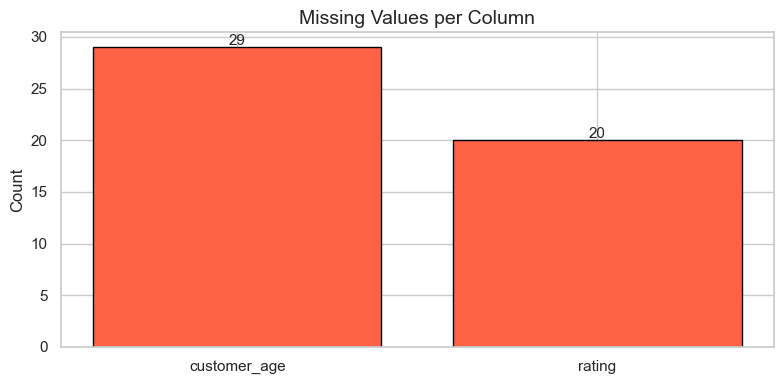

In [5]:
print('='*60)
print('STEP 2: MISSING VALUE ANALYSIS')
print('='*60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_report[missing_report['Missing Count'] > 0])

fig, ax = plt.subplots(figsize=(8, 4))
missing_nonzero = missing[missing > 0]
ax.bar(missing_nonzero.index, missing_nonzero.values, color='tomato', edgecolor='black')
for i, v in enumerate(missing_nonzero):
    ax.text(i, v + 0.2, str(v), ha='center', fontsize=11)
ax.set_title('Missing Values per Column', fontsize=14)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## STEP 3: Univariate Analysis (One Column at a Time)

**Univariate Analysis** focuses on analyzing a single variable independently to understand its distribution, central tendency, and spread.

### Why Perform Univariate Analysis?

It helps us:

- Understand how values are distributed
- Identify common and uncommon values
- Detect skewness in data
- Compare mean and median
- Spot potential outliers

---

### Numerical Variable Distributions

In this analysis, we examine the following numerical columns:

- `customer_age`
- `product_price`
- `quantity`
- `discount_pct`
- `sales_amount`
- `rating`

Each variable is visualized using a histogram.

---

### Understanding the Histogram

A histogram shows how frequently different values occur in a dataset.

It helps answer questions such as:

- Where are most values concentrated?
- Is the distribution symmetric or skewed?
- Are there unusually high or low values?
- How spread out is the data?

---

### Mean vs Median

Two reference lines are added to each histogram:

- **Red Dashed Line** → Mean (Average)
- **Orange Dashed Line** → Median (Middle Value)

#### Interpretation

- If Mean ≈ Median, the distribution is relatively symmetric.
- If Mean > Median, the data is positively (right) skewed.
- If Mean < Median, the data is negatively (left) skewed.

Comparing these values helps us better understand the shape of the distribution.

---

### Key Observations to Look For

While analyzing each histogram, pay attention to:

- Distribution shape
- Data concentration
- Skewness
- Range of values
- Presence of extreme values (outliers)

### Summary

Univariate Analysis provides a detailed understanding of each numerical feature individually and serves as the foundation for deeper analysis in later EDA steps.

STEP 3: UNIVARIATE ANALYSIS


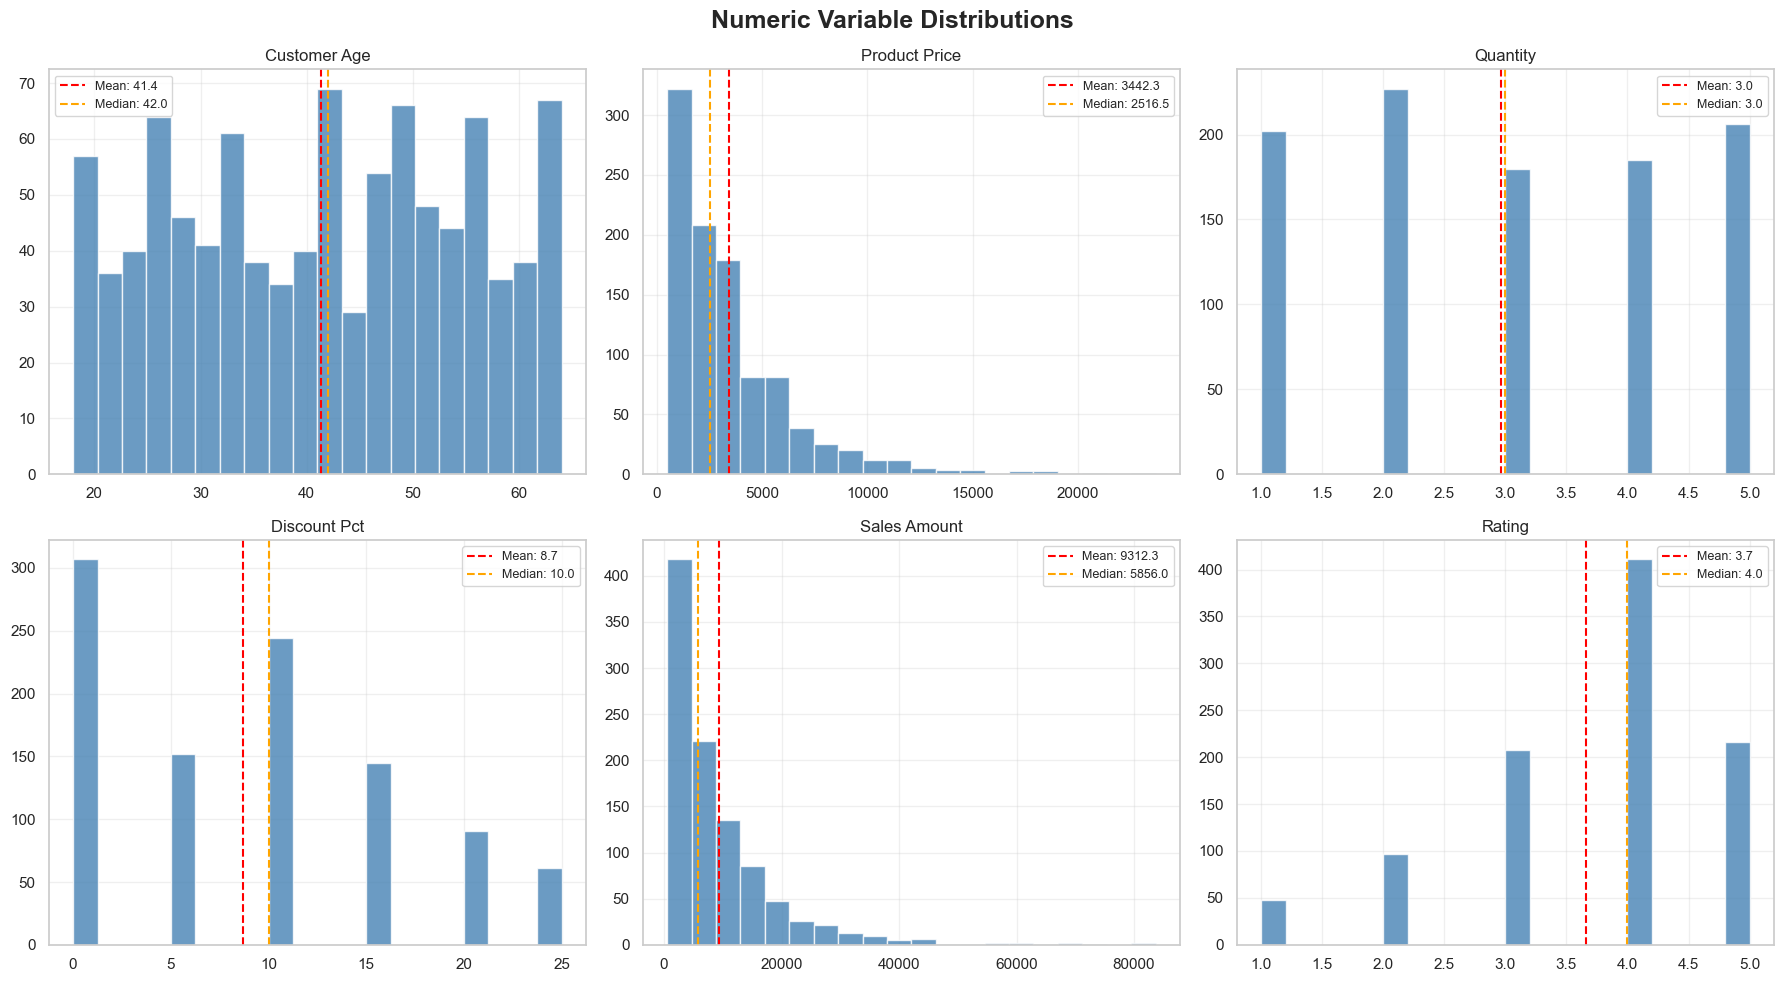

In [6]:
print('='*60)
print('STEP 3: UNIVARIATE ANALYSIS')
print('='*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Numeric Variable Distributions', fontsize=18, fontweight='bold')

numeric_cols = ['customer_age', 'product_price', 'quantity', 'discount_pct', 'sales_amount', 'rating']
for ax, col in zip(axes.flatten(), numeric_cols):
    data = df[col].dropna()
    ax.hist(data, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Categorical Variable Analysis

After analyzing numerical variables, we explore the distribution of **categorical variables**.

Categorical variables contain labels or categories rather than continuous numerical values.

### Why Analyze Categorical Variables?

Categorical analysis helps us:

- Understand the composition of the dataset
- Identify the most common categories
- Compare frequencies across groups
- Detect class imbalance
- Generate business insights

---

### Variables Analyzed

The following categorical columns are examined:

- `category`
- `region`
- `shipping_mode`
- `customer_gender`
- `rating`
- `returned`

---

### Understanding the Bar Chart

A bar chart displays the frequency (count) of each category.

The height of each bar represents the number of records belonging to that category.

This makes it easy to compare categories visually.

---

### Value Counts

For each column, `value_counts()` is used to calculate:

- Unique categories
- Number of occurrences of each category

This helps identify the most and least common values.

---

### What to Look For

While analyzing the charts, observe:

- Which categories appear most frequently
- Which categories are least common
- Whether the distribution is balanced
- Any unusual or unexpected patterns

Examples:

- Which product category receives the most orders?
- Which region contributes the highest number of sales?
- Which shipping method is most popular?
- What is the distribution of customer ratings?
- What percentage of products are returned?

---

### Summary

Categorical Variable Analysis helps us understand the composition of the dataset and provides valuable business insights about customer behavior, product preferences, and operational trends.

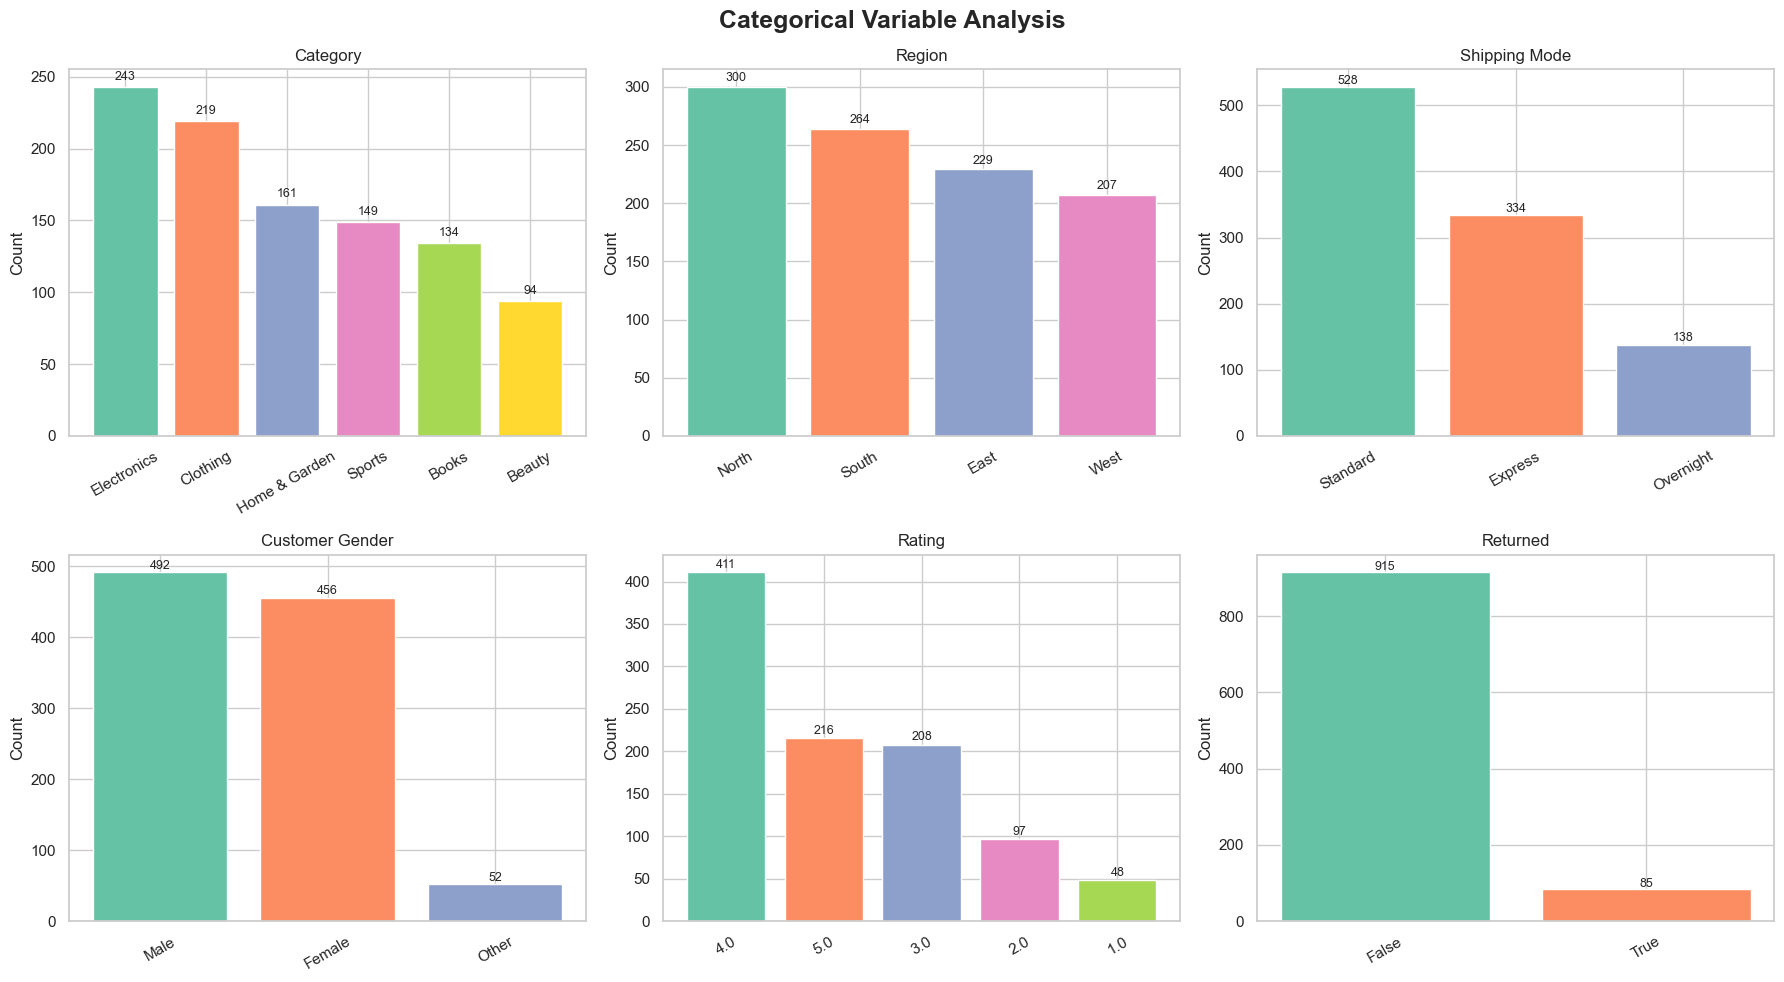

In [7]:
# Categorical column analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Categorical Variable Analysis', fontsize=18, fontweight='bold')

cat_cols = ['category', 'region', 'shipping_mode', 'customer_gender', 'rating', 'returned']
for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=plt.cm.Set2.colors[:len(counts)])
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## STEP 4: Bivariate Analysis (Two Variables Together)

**Bivariate Analysis** examines the relationship between two variables to identify patterns, trends, and possible business insights.

### Why Perform Bivariate Analysis?

It helps us answer questions such as:

- Which categories generate the highest sales?
- Which regions contribute the most revenue?
- Does product price affect sales amount?
- Do discounts influence customer ratings?

---

### 1. Average Sales by Category

This chart compares the **average sales amount** across different product categories.

#### Purpose

- Identify high-performing categories
- Compare revenue potential between categories
- Understand customer purchasing preferences

#### Interpretation

Higher bars indicate categories that generate larger average order values.

---

### 2. Total Sales by Region

A pie chart is used to show the contribution of each region to total sales.

#### Purpose

- Compare regional performance
- Identify top revenue-generating regions
- Understand market distribution

#### Interpretation

Larger slices represent regions contributing a greater share of overall sales.

---

### 3. Product Price vs Sales Amount

A scatter plot visualizes the relationship between product price and sales amount.

#### Purpose

- Identify trends between price and revenue
- Detect unusual observations
- Explore possible relationships

#### Interpretation

Each point represents an order.

Patterns in the plot help determine whether higher-priced products tend to generate higher sales amounts.

---

### 4. Average Rating by Discount Percentage

This chart compares customer ratings across different discount levels.

#### Purpose

- Understand the impact of discounts on customer satisfaction
- Compare average ratings for each discount percentage

#### Interpretation

Higher bars indicate discount levels associated with better customer ratings.

This can help businesses evaluate whether discounts improve customer experience.

---

### Summary

Bivariate Analysis helps uncover relationships between variables and provides deeper business insights than analyzing each column individually.

STEP 4: BIVARIATE ANALYSIS


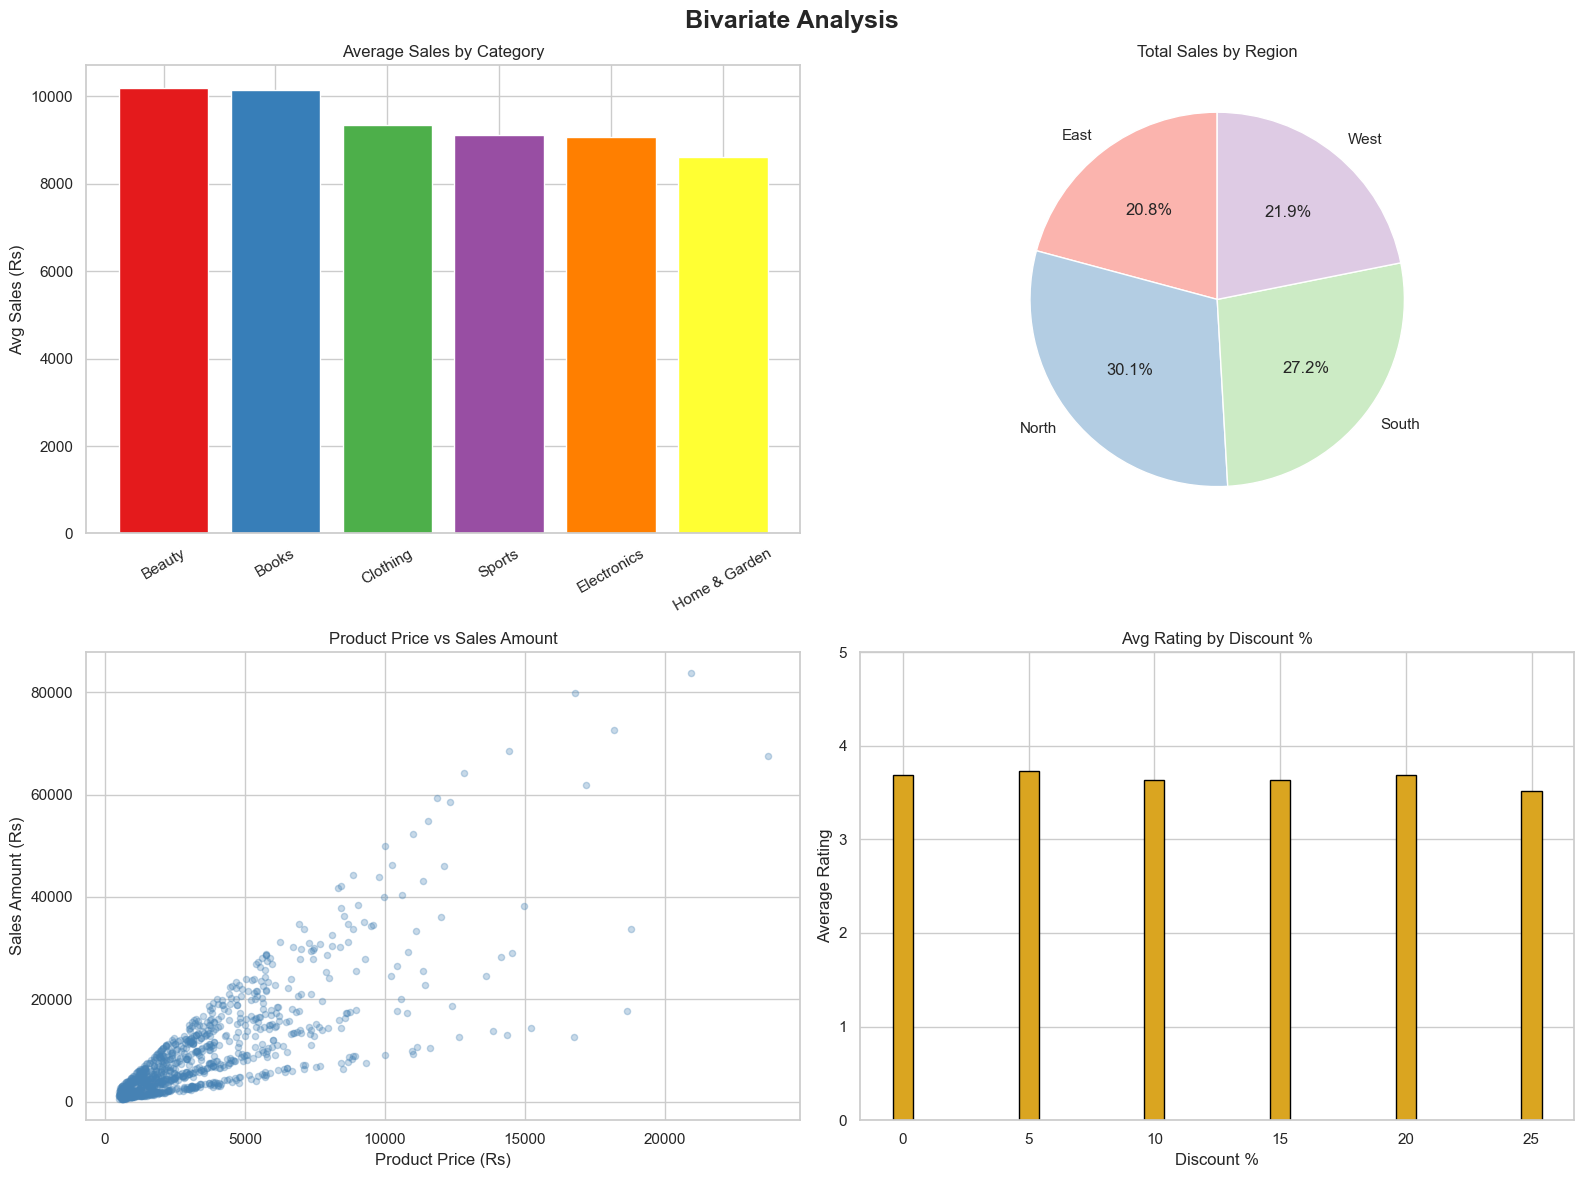

In [8]:
print('='*60)
print('STEP 4: BIVARIATE ANALYSIS')
print('='*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bivariate Analysis', fontsize=18, fontweight='bold')

# 1. Sales by Category
category_sales = df.groupby('category')['sales_amount'].mean().sort_values(ascending=False)
axes[0,0].bar(category_sales.index, category_sales.values, color=plt.cm.Set1.colors[:len(category_sales)])
axes[0,0].set_title('Average Sales by Category')
axes[0,0].set_ylabel('Avg Sales (Rs)')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Sales by Region
region_sales = df.groupby('region')['sales_amount'].sum()
axes[0,1].pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
              colors=plt.cm.Pastel1.colors[:4], startangle=90)
axes[0,1].set_title('Total Sales by Region')

# 3. Price vs Sales scatter
axes[1,0].scatter(df['product_price'], df['sales_amount'], alpha=0.3,
                  color='steelblue', s=20)
axes[1,0].set_title('Product Price vs Sales Amount')
axes[1,0].set_xlabel('Product Price (Rs)')
axes[1,0].set_ylabel('Sales Amount (Rs)')

# 4. Discount vs Rating
df_agg = df.groupby('discount_pct')['rating'].mean().dropna()
axes[1,1].bar(df_agg.index, df_agg.values, color='goldenrod', edgecolor='black')
axes[1,1].set_title('Avg Rating by Discount %')
axes[1,1].set_xlabel('Discount %')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

## Category vs Sales Amount (Box Plot Analysis)

This box plot compares the distribution of **sales amounts across different product categories**.

### Why Use a Box Plot?

A box plot provides more information than a simple bar chart because it shows:

- Median (middle value)
- Data spread
- Variability within each category
- Potential outliers
- Overall distribution of sales

---

### Understanding the Box Plot

Each box represents the sales distribution for a particular category.

#### Key Components

- **Middle Line** → Median sales amount
- **Box** → Middle 50% of the data (Interquartile Range)
- **Whiskers** → Typical range of values
- **Points Outside Whiskers** → Potential outliers

---

### What to Look For

While analyzing the chart, observe:

- Which category has the highest median sales
- Which category has the widest sales range
- Which category shows the most consistency
- Presence of unusually large sales values (outliers)
- Differences in customer spending across categories

---

### Business Importance

This analysis helps businesses:

- Identify high-value product categories
- Understand sales variability
- Detect categories with occasional large purchases
- Compare customer spending patterns across categories

### Summary

The box plot provides a detailed view of how sales amounts vary between product categories and helps identify both typical sales behavior and unusual high-value transactions.

/var/folders/gt/cn_67yq175bd9r_ck9p0nbm40000gn/T/ipykernel_6511/504940009.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='sales_amount', palette='Set2')


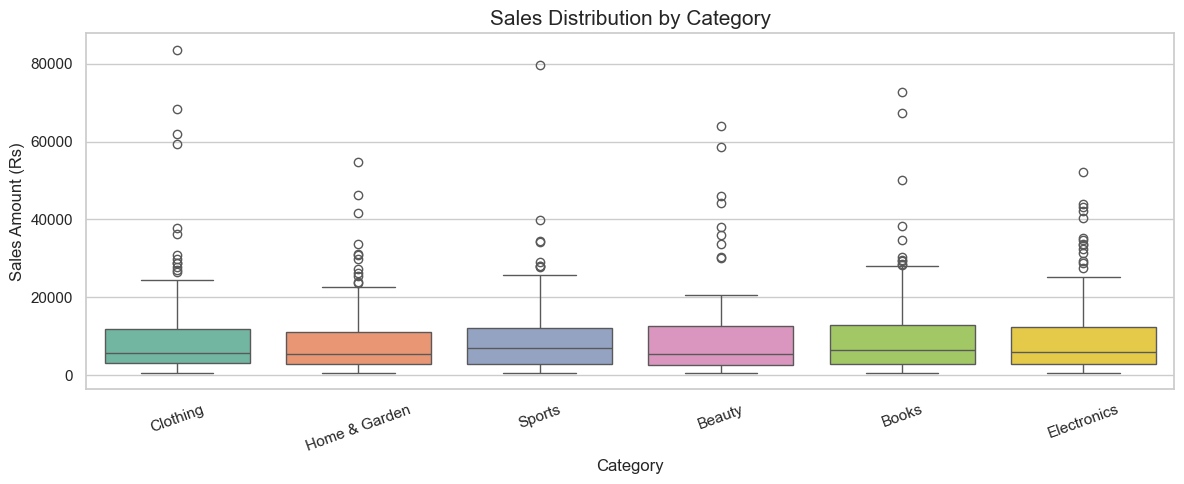

In [9]:
# Box plots — Category vs Sales
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='category', y='sales_amount', palette='Set2')
plt.title('Sales Distribution by Category', fontsize=15)
plt.xlabel('Category')
plt.ylabel('Sales Amount (Rs)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Time-Based Analysis (Monthly Trends)

Time-based analysis helps us understand how business performance changes over time.

By grouping data by month, we can identify trends, seasonality, and periods of high or low activity.

### Why Perform Time-Based Analysis?

It helps answer questions such as:

- Which months generate the highest sales?
- Which months receive the most orders?
- Are sales increasing or decreasing over time?
- Are there seasonal patterns in customer purchases?

---

### Monthly Sales Analysis

The dataset is grouped by month to calculate:

- **Total Sales**
- **Order Count**
- **Average Order Value**

This allows us to compare business performance across different months.

---

### 1. Monthly Total Sales

A line chart is used to visualize total sales throughout the year.

#### Purpose

- Track revenue trends over time
- Identify peak sales months
- Detect seasonal fluctuations

#### Interpretation

- Rising line → Increasing sales
- Falling line → Decreasing sales
- Peaks → Strong-performing months
- Valleys → Low-performing months

The shaded area improves visualization and makes trends easier to identify.

---

### 2. Monthly Order Count

A bar chart displays the total number of orders placed each month.

#### Purpose

- Measure customer activity
- Compare demand across months
- Identify busy and slow periods

#### Interpretation

Higher bars indicate months with greater customer purchasing activity.

Comparing order count with total sales can reveal whether revenue growth comes from:

- More orders
- Higher-value orders
- Or both

---

### Business Importance

Monthly trend analysis helps businesses:

- Plan inventory requirements
- Forecast future demand
- Schedule marketing campaigns
- Identify seasonal opportunities
- Improve operational planning

### Summary

Time-based analysis provides valuable insights into sales and customer activity throughout the year, helping businesses understand trends and make better strategic decisions.

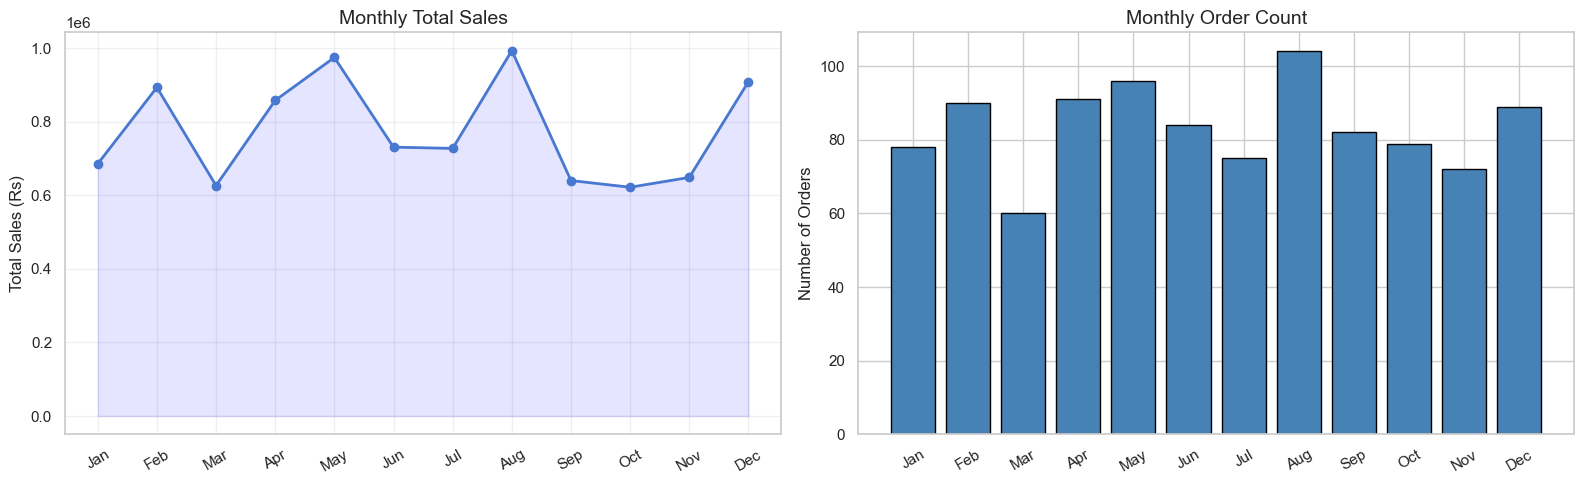

In [10]:
# Time-based analysis
monthly = df.groupby('month_num').agg(
    total_sales=('sales_amount', 'sum'),
    order_count=('order_id', 'count'),
    avg_order_value=('sales_amount', 'mean')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = [month_names[m-1] for m in monthly['month_num']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly['month_num'], monthly['total_sales'], 'b-o', linewidth=2)
axes[0].fill_between(monthly['month_num'], monthly['total_sales'], alpha=0.1, color='blue')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=30)
axes[0].set_title('Monthly Total Sales', fontsize=14)
axes[0].set_ylabel('Total Sales (Rs)')
axes[0].grid(True, alpha=0.3)

axes[1].bar(monthly['month_num'], monthly['order_count'], color='steelblue', edgecolor='black')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=30)
axes[1].set_title('Monthly Order Count', fontsize=14)
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

## STEP 5: Multivariate Analysis

**Multivariate Analysis** involves analyzing three or more variables simultaneously to uncover deeper patterns and relationships within the data.

Unlike univariate and bivariate analysis, multivariate analysis helps us understand how multiple factors interact together.

---

### Sales by Category and Region

In this analysis, we examine:

- **Category**
- **Region**
- **Sales Amount**

A pivot table is created to summarize the total sales generated by each category in each region.

---

### Why Use a Pivot Table?

A pivot table helps us:

- Aggregate large amounts of data
- Compare multiple dimensions at once
- Identify high-performing combinations
- Generate business insights quickly

Rows represent product categories, while columns represent regions.

Each cell contains the total sales amount for that category-region combination.

---

### Understanding the Heatmap

The pivot table is visualized using a heatmap.

#### Purpose

- Compare sales performance across categories and regions
- Quickly identify patterns
- Highlight strong and weak performing segments

#### Color Interpretation

- **Darker colors** → Higher sales
- **Lighter colors** → Lower sales

This makes it easy to spot areas with strong revenue generation.

---

### What to Look For

While analyzing the heatmap, observe:

- Which category performs best overall
- Which region generates the highest sales
- High-performing category-region combinations
- Low-performing segments that may need attention

---

### Business Importance

This analysis helps businesses:

- Identify profitable markets
- Understand regional product preferences
- Optimize inventory planning
- Improve marketing strategies
- Focus resources on high-performing segments

### Summary

The heatmap provides a clear visual representation of sales performance across multiple dimensions, helping uncover insights that may not be visible through simple charts or individual analyses.

STEP 5: MULTIVARIATE ANALYSIS


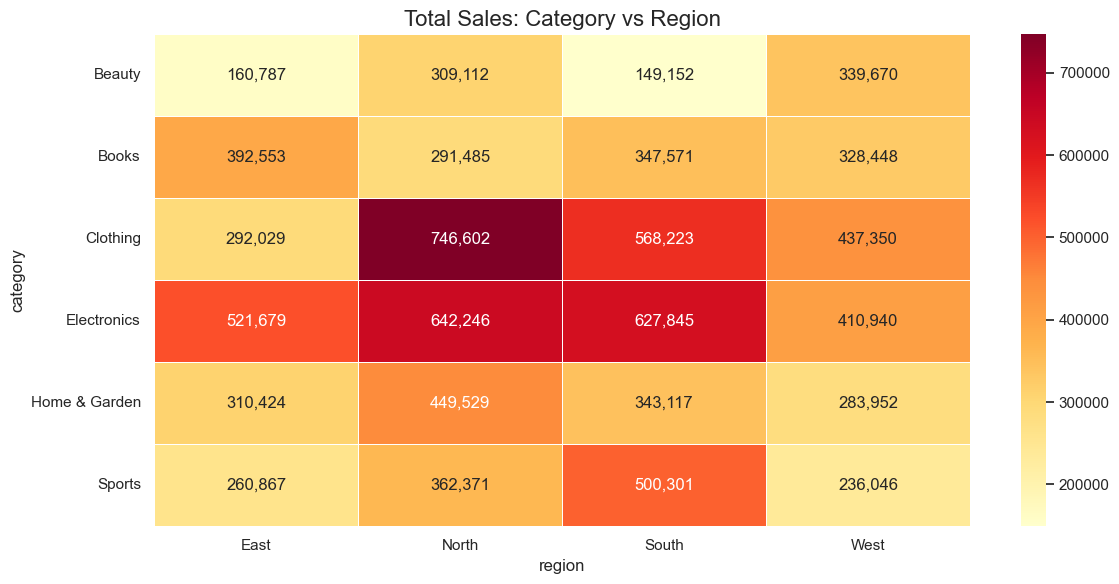

In [11]:
print('='*60)
print('STEP 5: MULTIVARIATE ANALYSIS')
print('='*60)

# Sales by Category and Region
pivot = df.pivot_table(values='sales_amount', index='category', columns='region', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd', linewidths=0.5)
plt.title('Total Sales: Category vs Region', fontsize=16)
plt.tight_layout()
plt.show()

## Category and Gender Analysis

This analysis examines how **average sales amount varies across product categories and customer genders**.

It combines three variables:

- Product Category
- Customer Gender
- Sales Amount

Therefore, it is a form of **Multivariate Analysis**.

---

### Why Perform This Analysis?

This visualization helps answer questions such as:

- Do spending patterns differ by gender?
- Which product categories generate higher sales for specific genders?
- Are certain categories more popular among particular customer groups?

Understanding these patterns can help businesses improve targeting and marketing strategies.

---

### Grouping the Data

The data is grouped by:

```python
category + customer_gender

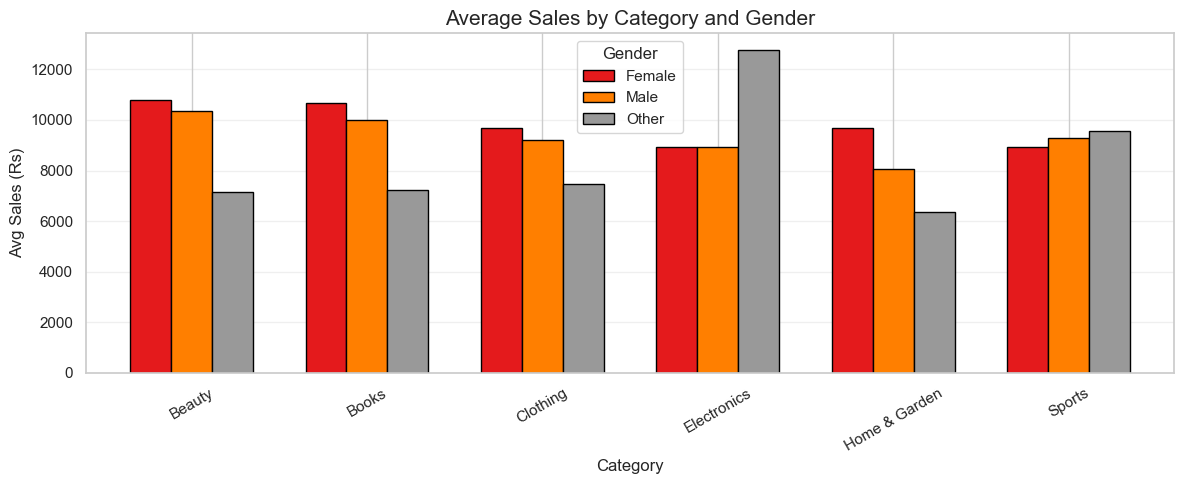

In [12]:
# Gender and Category
fig, ax = plt.subplots(figsize=(12, 5))
pivot2 = df.groupby(['category', 'customer_gender'])['sales_amount'].mean().unstack()
pivot2.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='black', width=0.7)
ax.set_title('Average Sales by Category and Gender', fontsize=15)
ax.set_xlabel('Category')
ax.set_ylabel('Avg Sales (Rs)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Gender')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 6: Correlation Analysis

Correlation Analysis helps us measure the strength and direction of relationships between numerical variables.

The correlation coefficient ranges from **-1 to +1**:

- **+1** → Perfect Positive Correlation
- **0** → No Correlation
- **-1** → Perfect Negative Correlation

---

### Correlation Matrix

A correlation matrix is created using numerical variables:

- `customer_age`
- `product_price`
- `quantity`
- `discount_pct`
- `sales_amount`
- `rating`

The matrix shows the correlation coefficient between every pair of variables.

---

### Understanding the Heatmap

The correlation matrix is visualized using a heatmap.

#### Color Interpretation

- **Red Shades** → Positive Correlation
- **Blue Shades** → Negative Correlation
- **Light Colors** → Weak Correlation

The values displayed inside the cells represent the actual correlation coefficients.

---

### Key Relationships to Analyze

#### Sales Amount vs Product Price

Measures whether expensive products generate higher sales amounts.

- Positive correlation indicates higher-priced products contribute to larger sales values.
- Stronger values indicate a stronger relationship.

---

#### Sales Amount vs Quantity

Measures the relationship between the number of items purchased and total sales.

- Positive correlation is expected because purchasing more products usually increases sales amount.

---

#### Rating vs Discount Percentage

Measures whether discounts influence customer ratings.

- Positive correlation suggests ratings increase with discounts.
- Negative correlation suggests ratings decrease as discounts increase.
- Values close to zero indicate little or no relationship.

---

### Why Correlation Analysis is Important

Correlation Analysis helps us:

- Identify important relationships in the dataset
- Understand factors affecting sales performance
- Detect highly related variables
- Support business decision-making
- Prepare data for predictive modeling

### Summary

Correlation Analysis provides a quantitative view of how numerical variables interact with each other and helps uncover meaningful patterns hidden within the data.

STEP 6: CORRELATION ANALYSIS


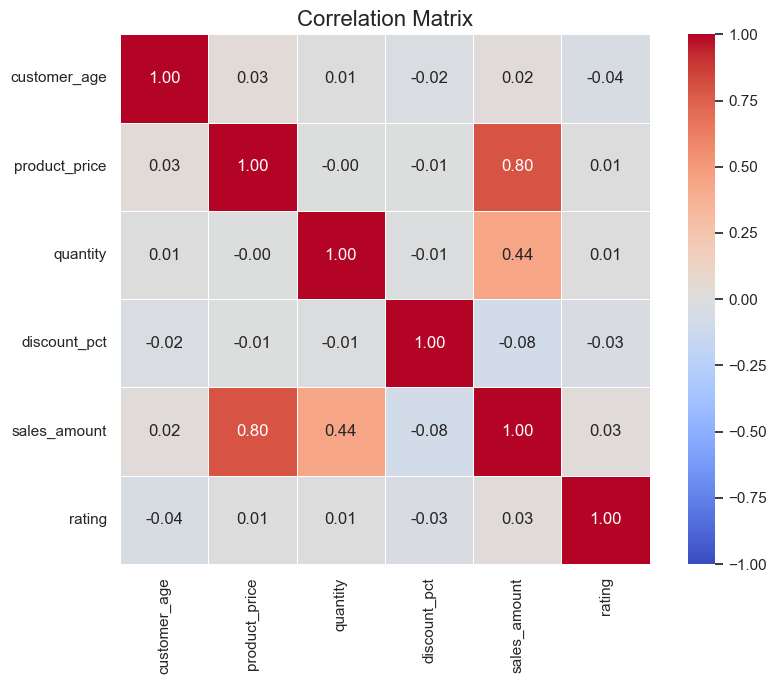


Key Observations:
- sales_amount vs product_price correlation: 0.8
- sales_amount vs quantity correlation: 0.44
- rating vs discount_pct correlation: -0.03


In [13]:
print('='*60)
print('STEP 6: CORRELATION ANALYSIS')
print('='*60)

numeric_df = df[['customer_age', 'product_price', 'quantity', 'discount_pct', 'sales_amount', 'rating']]
corr = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

print('\nKey Observations:')
print('- sales_amount vs product_price correlation:', round(corr.loc['sales_amount', 'product_price'], 2))
print('- sales_amount vs quantity correlation:', round(corr.loc['sales_amount', 'quantity'], 2))
print('- rating vs discount_pct correlation:', round(corr.loc['rating', 'discount_pct'], 2))

## STEP 7: Business Insights (KPI Summary)

The final step of EDA is to convert data analysis into meaningful business insights.

This section focuses on calculating key performance indicators (KPIs) that summarize overall business performance.

---

### Key Performance Indicators (KPIs)

#### Total Revenue

```python
df['sales_amount'].sum()
```

Represents the total revenue generated from all orders.

**Business Use:**
- Measures overall business performance.
- Helps evaluate revenue growth and profitability.

---

#### Total Orders

```python
len(df)
```

Shows the total number of orders placed by customers.

**Business Use:**
- Indicates customer activity and demand.
- Helps measure sales volume.

---

#### Average Order Value (AOV)

```python
df['sales_amount'].mean()
```

Represents the average revenue generated per order.

**Business Use:**
- Measures customer spending behavior.
- Helps evaluate upselling and cross-selling strategies.

---

#### Return Rate

```python
df['returned'].mean() * 100
```

Calculates the percentage of orders that were returned.

**Business Use:**
- Measures product quality and customer satisfaction.
- High return rates may indicate potential issues.

---

#### Average Customer Rating

```python
df['rating'].mean()
```

Represents the average customer satisfaction score.

**Business Use:**
- Evaluates customer experience.
- Helps identify overall service quality.

---

#### Best Performing Category

```python
df.groupby('category')['sales_amount'].sum().idxmax()
```

Identifies the product category generating the highest total sales.

**Business Use:**
- Reveals top-performing products.
- Helps prioritize inventory and marketing efforts.

---

#### Best Performing Region

```python
df.groupby('region')['sales_amount'].sum().idxmax()
```

Identifies the region contributing the highest revenue.

**Business Use:**
- Highlights strong markets.
- Supports regional expansion decisions.

---

#### Best Performing Month

```python
df.groupby('month_num')['sales_amount'].sum().idxmax()
```

Identifies the month with the highest sales.

**Business Use:**
- Detects seasonal trends.
- Helps plan promotions and inventory management.

---

### Why Business Insights Matter

EDA is not only about statistics and visualizations. The ultimate goal is to transform raw data into actionable business knowledge.

These KPIs provide a quick summary of:

- Revenue performance
- Customer behavior
- Product performance
- Regional performance
- Seasonal trends
- Customer satisfaction

### Summary

The KPI Summary converts analytical findings into business-focused insights, helping organizations make informed decisions and improve overall performance.

In [14]:
print('='*60)
print('STEP 7: BUSINESS INSIGHTS')
print('='*60)

total_revenue  = df['sales_amount'].sum()
avg_order_val  = df['sales_amount'].mean()
total_orders   = len(df)
return_rate    = df['returned'].mean() * 100
avg_rating     = df['rating'].mean()
best_category  = df.groupby('category')['sales_amount'].sum().idxmax()
best_region    = df.groupby('region')['sales_amount'].sum().idxmax()
best_month_num = df.groupby('month_num')['sales_amount'].sum().idxmax()
best_month     = month_names[best_month_num - 1]

print(f'\n--- KEY PERFORMANCE INDICATORS ---')
print(f'Total Revenue      : Rs {total_revenue:>12,}')
print(f'Total Orders       : {total_orders:>12,}')
print(f'Avg Order Value    : Rs {avg_order_val:>11,.0f}')
print(f'Return Rate        : {return_rate:>11.1f}%')
print(f'Avg Customer Rating: {avg_rating:>11.2f}/5')
print(f'Best Category      : {best_category:>12}')
print(f'Best Region        : {best_region:>12}')
print(f'Best Month         : {best_month:>12}')

STEP 7: BUSINESS INSIGHTS

--- KEY PERFORMANCE INDICATORS ---
Total Revenue      : Rs    9,312,299
Total Orders       :        1,000
Avg Order Value    : Rs       9,312
Return Rate        :         8.5%
Avg Customer Rating:        3.66/5
Best Category      :  Electronics
Best Region        :        North
Best Month         :          Aug


## Additional Business Insights

To gain deeper business understanding, we can analyze customer value and category performance.

---

### Top 5 Customers by Revenue

A customer-wise revenue analysis is performed by grouping data using `customer_id` and calculating total sales generated by each customer.

```python
df.groupby('customer_id')['sales_amount'].sum()
```

The top 5 customers with the highest revenue contribution are identified.

#### Why is this Important?

High-value customers are extremely important for business growth because they contribute a significant portion of total revenue.

This analysis helps businesses:

- Identify VIP customers
- Create loyalty programs
- Offer personalized promotions
- Improve customer retention

---

### Category Performance Summary

A category-wise performance report is created using multiple business metrics.

The following KPIs are calculated for each category:

#### Orders

Total number of orders placed within each category.

**Business Use:**
- Measures category popularity.

---

#### Total Revenue

Total sales generated by each category.

**Business Use:**
- Identifies top revenue-generating categories.

---

#### Average Order Value

Average revenue per order within a category.

**Business Use:**
- Helps understand customer spending behavior.

---

#### Average Rating

Average customer rating received by products in a category.

**Business Use:**
- Measures customer satisfaction.

---

#### Return Count

Total number of returned orders within each category.

**Business Use:**
- Helps identify quality or fulfillment issues.

---

#### Return Rate %

Calculated as:

```python
(Return_Count / Orders) * 100
```

This metric shows the percentage of orders returned in each category.

**Business Use:**
- Evaluates product reliability.
- Identifies categories with higher return risks.

---

### Why Category Performance Analysis Matters

This summary provides a complete view of category performance by combining:

- Sales performance
- Customer satisfaction
- Product returns
- Order volume

It helps businesses:

- Focus on profitable categories
- Improve underperforming categories
- Optimize inventory planning
- Make data-driven strategic decisions

### Summary

Customer value analysis identifies the most valuable customers, while category performance analysis provides a comprehensive view of how different product categories contribute to overall business success.

In [15]:
# Top 5 customers by value (simulated)
df['customer_id'] = np.random.randint(1, 201, n)
top_customers = df.groupby('customer_id')['sales_amount'].sum().nlargest(5)
print('\nTop 5 Customers by Revenue:')
for rank, (cid, rev) in enumerate(top_customers.items(), 1):
    print(f'  {rank}. Customer {cid}: Rs {rev:,}')

# Category performance table
print('\nCategory Performance Summary:')
cat_perf = df.groupby('category').agg(
    Orders=('order_id', 'count'),
    Total_Revenue=('sales_amount', 'sum'),
    Avg_Order=('sales_amount', 'mean'),
    Avg_Rating=('rating', 'mean'),
    Return_Count=('returned', 'sum')
).round(1)
cat_perf['Return_Rate%'] = (cat_perf['Return_Count'] / cat_perf['Orders'] * 100).round(1)
print(cat_perf.sort_values('Total_Revenue', ascending=False))


Top 5 Customers by Revenue:
  1. Customer 7: Rs 143,854
  2. Customer 83: Rs 130,777
  3. Customer 2: Rs 128,784
  4. Customer 173: Rs 128,784
  5. Customer 92: Rs 117,115

Category Performance Summary:
               Orders  Total_Revenue  Avg_Order  Avg_Rating  Return_Count  \
category                                                                    
Electronics       243        2202710     9064.7         3.7            24   
Clothing          219        2044204     9334.3         3.6            16   
Home & Garden     161        1387022     8615.0         3.7            14   
Books             134        1360057    10149.7         3.7            14   
Sports            149        1359585     9124.7         3.7             8   
Beauty             94         958721    10199.2         3.7             9   

               Return_Rate%  
category                     
Electronics             9.9  
Clothing                7.3  
Home & Garden           8.7  
Books                  10.4  

## Final EDA Dashboard

The final dashboard combines multiple analyses into a single view, providing a comprehensive summary of business performance and customer behavior.

Dashboards help analysts and decision-makers quickly understand key trends without reviewing multiple charts separately.

---

### 1. Monthly Revenue Trend

A line chart displays total revenue generated each month.

#### Purpose

- Monitor sales trends over time
- Identify peak and low-performing months
- Detect seasonality in customer purchases

#### Business Insight

Consistent growth indicates improving business performance, while sudden drops may require further investigation.

---

### 2. Revenue by Category

A pie chart shows the percentage contribution of each product category to total revenue.

#### Purpose

- Compare category performance
- Identify top revenue-generating categories
- Understand product portfolio contribution

#### Business Insight

Categories contributing the largest share of revenue often deserve greater marketing and inventory focus.

---

### 3. Sales Amount Distribution

A histogram visualizes the distribution of order values.

#### Purpose

- Understand customer spending patterns
- Identify common order values
- Detect unusually large transactions

#### Business Insight

The mean reference line helps compare typical spending behavior with the overall distribution.

---

### 4. Revenue by Region

A bar chart compares total revenue across regions.

#### Purpose

- Evaluate regional performance
- Identify strong and weak markets
- Support geographic business decisions

#### Business Insight

High-performing regions may present opportunities for expansion, while lower-performing regions may require targeted strategies.

---

### 5. Customer Rating Distribution

A bar chart displays the frequency of customer ratings.

#### Purpose

- Measure customer satisfaction
- Understand rating trends
- Identify service quality levels

#### Business Insight

A larger concentration of higher ratings generally indicates positive customer experiences.

---

### 6. Return Rate by Category

A bar chart shows the percentage of returned orders for each category.

#### Purpose

- Compare return behavior across categories
- Identify products with potential quality issues
- Evaluate customer satisfaction indirectly

#### Business Insight

Categories with higher return rates may require improvements in product quality, descriptions, packaging, or delivery processes.

---

## Dashboard Benefits

This dashboard brings together insights from:

- Sales Performance
- Customer Behavior
- Product Performance
- Regional Analysis
- Customer Satisfaction
- Return Analysis

into a single visual report.

---

## Conclusion

Through EDA, we transformed raw e-commerce data into meaningful business insights by:

- Understanding dataset structure
- Identifying missing values
- Exploring numerical and categorical variables
- Analyzing relationships between features
- Studying trends over time
- Evaluating correlations
- Generating business-focused KPIs

This process helps organizations make informed, data-driven decisions and serves as the foundation for advanced analytics and machine learning projects.

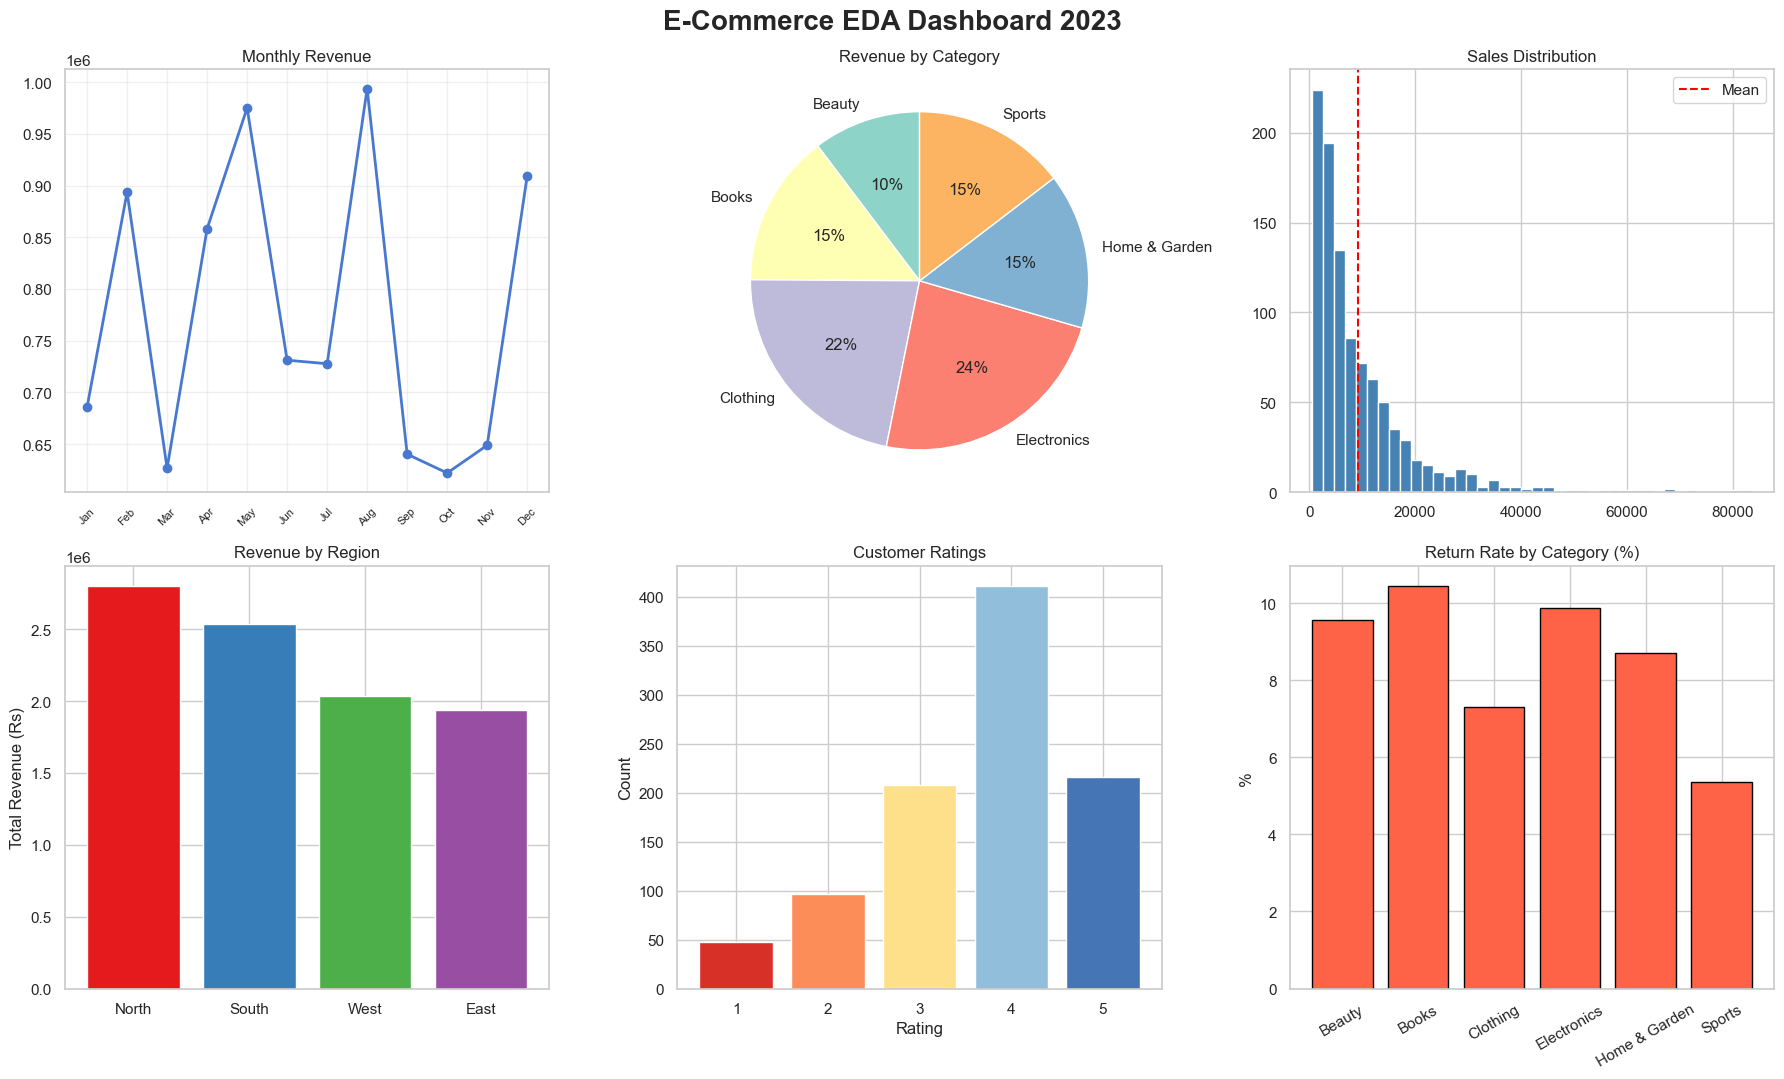

In [16]:
# Final EDA Dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('E-Commerce EDA Dashboard 2023', fontsize=20, fontweight='bold')

# 1. Monthly revenue
axes[0,0].plot(range(1,13), monthly['total_sales'], 'b-o', lw=2)
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(month_names, rotation=45, fontsize=8)
axes[0,0].set_title('Monthly Revenue')
axes[0,0].grid(True, alpha=0.3)

# 2. Category share
cat_rev = df.groupby('category')['sales_amount'].sum()
axes[0,1].pie(cat_rev, labels=cat_rev.index, autopct='%1.0f%%',
              colors=plt.cm.Set3.colors, startangle=90)
axes[0,1].set_title('Revenue by Category')

# 3. Sales amount distribution
axes[0,2].hist(df['sales_amount'], bins=40, color='steelblue', edgecolor='white')
axes[0,2].axvline(df['sales_amount'].mean(), color='red', linestyle='--', label='Mean')
axes[0,2].set_title('Sales Distribution')
axes[0,2].legend()

# 4. Region comparison
reg = df.groupby('region')['sales_amount'].sum().sort_values(ascending=False)
axes[1,0].bar(reg.index, reg.values, color=plt.cm.Set1.colors[:4])
axes[1,0].set_title('Revenue by Region')
axes[1,0].set_ylabel('Total Revenue (Rs)')

# 5. Rating distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[1,1].bar(rating_counts.index, rating_counts.values,
              color=['#d73027','#fc8d59','#fee08b','#91bfdb','#4575b4'])
axes[1,1].set_title('Customer Ratings')
axes[1,1].set_xlabel('Rating')
axes[1,1].set_ylabel('Count')

# 6. Return rate by category
return_rate_cat = df.groupby('category')['returned'].mean() * 100
axes[1,2].bar(return_rate_cat.index, return_rate_cat.values, color='tomato', edgecolor='black')
axes[1,2].set_title('Return Rate by Category (%)')
axes[1,2].tick_params(axis='x', rotation=30)
axes[1,2].set_ylabel('%')

plt.tight_layout()
plt.show()

---
## EDA Checklist — Every Analyst Must Do This

| Step | Question | Tools |
|------|----------|-------|
| 1. Overview | How big is the data? What columns? | `.shape`, `.info()`, `.head()` |
| 2. Missing | What is missing? How much? | `.isnull().sum()` |
| 3. Univariate | What's the distribution of each column? | `hist()`, `boxplot()` |
| 4. Bivariate | How do two variables relate? | `scatter()`, `groupby()` |
| 5. Multivariate | Any patterns across 3+ variables? | `heatmap()`, `pairplot()` |
| 6. Correlation | Which columns are strongly related? | `.corr()`, `heatmap()` |
| 7. Insights | What does the data tell the business? | Summary stats, KPIs |

---
## Homework

1. Download the Titanic dataset and run full EDA
2. Answer: What factors affected survival?
3. Create a 3x3 dashboard with key insights
4. Write 5 business recommendations from the data
5. Share your findings as if presenting to a manager